In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats

In [3]:
# Style Setup
sns.set_theme(style="whitegrid")
MODEL_COLORS = {"gemma": "#E63946", "qwen": "#2A9D8F", "llama": "#457B9D"}

In [2]:
src_path = "combined_df.csv"
df = pd.read_csv(src_path)
df.head()

,Unnamed: 0,model,step,checkpoint,checkpoint_task,fomc,numgluecm,scienceqa,fomc_std,scienceqa_std,...,delta_curr_vs_base_std,avg_over_all_tasks,avg_over_all_tasks_std,next_task,op,op_std,bwt,bwt_std,fwt,fwt_std
0,0,qwen,0,Base,base,0.250,0.370,0.520,0.000,0.000,...,NaN,0.380,0.000,task_1,—,NaN,—,NaN,0.000,0.000
1,1,qwen,1,After task_1,task_1,0.533,0.379,0.660,0.076,0.035,...,0.076,0.524,0.029,task_2,0.533,0.076,—,NaN,0.074,0.012
2,2,qwen,2,After task_2,task_2,0.540,0.490,0.800,0.053,0.000,...,0.000,0.610,0.012,task_3,0.670,0.026,0.007,0.075,0.119,0.026
3,3,qwen,3,After task_3,task_3,0.577,0.379,0.817,0.042,0.006,...,0.056,0.591,0.012,—,0.591,0.012,0.030,0.023,—,NaN
4,0,gemma,0,Base,base,0.220,0.370,0.620,0.000,0.000,...,NaN,0.403,0.000,task_1,—,NaN,—,NaN,0.000,0.000


In [16]:
src_path = "combined_df_321.csv"
df_321 = pd.read_csv(src_path)
df_321.head()

,Unnamed: 0,model,step,checkpoint,checkpoint_task,fomc,numgluecm,scienceqa,fomc_std,scienceqa_std,...,delta_curr_vs_base_std,avg_over_all_tasks,avg_over_all_tasks_std,next_task,op,op_std,bwt,bwt_std,fwt,fwt_std
0,0,qwen,0,Base,base,0.250,0.370,0.520,0.000,0.000,...,NaN,0.380,0.000,task_3,—,NaN,—,NaN,0.000,0.000
1,1,qwen,1,After task_3,task_3,0.287,0.185,0.693,0.012,0.035,...,0.098,0.388,0.035,task_2,0.185,0.098,—,NaN,0.105,0.018
2,2,qwen,2,After task_2,task_2,0.287,0.235,0.817,0.029,0.012,...,0.012,0.446,0.007,task_1,0.526,0.014,0.049,0.074,0.037,0.029
3,3,qwen,3,After task_1,task_1,0.620,0.255,0.820,0.035,0.010,...,0.035,0.565,0.020,—,0.565,0.020,0.037,0.026,—,NaN
4,0,gemma,0,Base,base,0.220,0.370,0.620,0.000,0.000,...,NaN,0.403,0.000,task_3,—,NaN,—,NaN,0.000,0.000


In [13]:
def process_df_columns(df_to_process):
    # Target ONLY the columns that should be numbers
    numeric_cols = [
        'fomc', 'numgluecm', 'scienceqa', 'fomc_std', 'scienceqa_std', 'numgluecm_std',
        'entropy_mean', 'margin_mean', 'kl_to_base_mean', 'entropy_mean_std', 
        'margin_mean_std', 'kl_to_base_mean_std', 'curr_accuracy', 'curr_accuracy_std',
        'avg_over_all_tasks', 'avg_over_all_tasks_std', 'op', 'op_std', 'bwt', 'bwt_std', 'fwt', 'fwt_std'
    ]

    # Ensure 'model' stays a string and replace the dashes before converting metrics
    df_to_process['model'] = df_to_process['model'].astype(str)

    for col in numeric_cols:
        if col in df_to_process.columns:
            # Convert to string, replace dash, then convert to numeric
            df_to_process[col] = pd.to_numeric(df_to_process[col].astype(str).replace('—', None), errors='coerce')

def plot_drift_vs_performance(dataframe):
    fig, ax1 = plt.subplots(figsize=(12, 4))
    ax2 = ax1.twinx()
    
    for model in dataframe['model'].unique():
        m_df = dataframe[dataframe['model'] == model]
        color = MODEL_COLORS.get(model, "gray")
        
        # Accuracy
        ax1.errorbar(m_df['step'], m_df['avg_over_all_tasks'], yerr=m_df['avg_over_all_tasks_std'], 
                     marker='o', label=f"{model.capitalize()} Acc", color=color, linewidth=2)
        # KL Divergence
        ax2.errorbar(m_df['step'], m_df['kl_to_base_mean'], yerr=m_df['kl_to_base_mean_std'], 
                     marker='x', linestyle='--', label=f"{model.capitalize()} KL", color=color)

    ax1.set_xticks([0, 1, 2, 3])
    ax1.set_xlabel("Sequential Step", fontweight='bold')
    ax1.set_ylabel("Avg Accuracy", fontweight='bold')
    ax2.set_ylabel("KL to Base (Drift)", fontweight='bold')
    plt.title("Model Drift vs. Performance Decay", fontsize=14, fontweight='bold')
    
    # Combined legend outside
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, loc='upper left', bbox_to_anchor=(1.15, 1))
    plt.tight_layout()
    plt.show()

def plot_stability_correlations(dataframe):
    # Filter Step 0 for degradation analysis
    df_filtered = dataframe[dataframe['step'] != 0]
    metrics = ['kl_to_base_mean', 'entropy_mean', 'margin_mean']
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for i, metric in enumerate(metrics):
        ax = axes[i]
        valid_df = df_filtered.dropna(subset=[metric, 'avg_over_all_tasks'])
        r, _ = stats.pearsonr(valid_df[metric], valid_df['avg_over_all_tasks'])
        
        sns.regplot(data=valid_df, x=metric, y='avg_over_all_tasks', scatter=False, ax=ax, color='gray', line_kws={'linestyle':'--'})
        sns.scatterplot(data=valid_df, x=metric, y='avg_over_all_tasks', hue='model', s=100, palette=MODEL_COLORS, ax=ax)
        
        ax.set_title(f"{metric.replace('_', ' ').capitalize()}\nr = {r:.3f}", fontweight='bold')
        if i > 0: ax.set_ylabel("")
        if i < 2: ax.get_legend().remove()
        else: ax.legend(bbox_to_anchor=(1.05, 1))

    plt.tight_layout()
    plt.show()

def plot_task_sensitivity(dataframe):
    df_filtered = dataframe[dataframe['step'] != 0]
    tasks = ['fomc', 'scienceqa', 'numgluecm']
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
    
    for i, task in enumerate(tasks):
        ax = axes[i]
        subset = df_filtered.dropna(subset=['kl_to_base_mean', task])
        r, _ = stats.pearsonr(subset['kl_to_base_mean'], subset[task])
        
        sns.regplot(data=subset, x='kl_to_base_mean', y=task, scatter=False, ax=ax, color='gray', line_kws={'alpha':0.3})
        sns.scatterplot(data=subset, x='kl_to_base_mean', y=task, hue='model', s=150, palette=MODEL_COLORS, ax=ax)
        
        # Add Step Annotations
        for _, row in subset.iterrows():
            ax.text(row['kl_to_base_mean'] + 0.02, row[task] + 0.01, str(int(row['step'])), fontsize=9, fontweight='bold')

        ax.set_title(f"{task.upper()} Sensitivity\nr = {r:.3f}", fontweight='bold')
        if i < 2: ax.get_legend().remove()
        else: ax.legend(bbox_to_anchor=(1.05, 1))

    plt.tight_layout()
    plt.show()

In [ ]:
process_df_columns(df_to_process=df)
df.head()

,Unnamed: 0,model,step,checkpoint,checkpoint_task,fomc,numgluecm,scienceqa,fomc_std,scienceqa_std,...,delta_curr_vs_base_std,avg_over_all_tasks,avg_over_all_tasks_std,next_task,op,op_std,bwt,bwt_std,fwt,fwt_std
0,0,qwen,0,Base,base,0.250,0.370,0.520,0.000,0.000,...,NaN,0.380,0.000,task_1,NaN,NaN,NaN,NaN,0.000,0.000
1,1,qwen,1,After task_1,task_1,0.533,0.379,0.660,0.076,0.035,...,0.076,0.524,0.029,task_2,0.533,0.076,NaN,NaN,0.074,0.012
2,2,qwen,2,After task_2,task_2,0.540,0.490,0.800,0.053,0.000,...,0.000,0.610,0.012,task_3,0.670,0.026,0.007,0.075,0.119,0.026
3,3,qwen,3,After task_3,task_3,0.577,0.379,0.817,0.042,0.006,...,0.056,0.591,0.012,—,0.591,0.012,0.030,0.023,NaN,NaN
4,0,gemma,0,Base,base,0.220,0.370,0.620,0.000,0.000,...,NaN,0.403,0.000,task_1,NaN,NaN,NaN,NaN,0.000,0.000


In [17]:
process_df_columns(df_to_process=df_321)
df_321.head()

,Unnamed: 0,model,step,checkpoint,checkpoint_task,fomc,numgluecm,scienceqa,fomc_std,scienceqa_std,...,delta_curr_vs_base_std,avg_over_all_tasks,avg_over_all_tasks_std,next_task,op,op_std,bwt,bwt_std,fwt,fwt_std
0,0,qwen,0,Base,base,0.250,0.370,0.520,0.000,0.000,...,NaN,0.380,0.000,task_3,NaN,NaN,NaN,NaN,0.000,0.000
1,1,qwen,1,After task_3,task_3,0.287,0.185,0.693,0.012,0.035,...,0.098,0.388,0.035,task_2,0.185,0.098,NaN,NaN,0.105,0.018
2,2,qwen,2,After task_2,task_2,0.287,0.235,0.817,0.029,0.012,...,0.012,0.446,0.007,task_1,0.526,0.014,0.049,0.074,0.037,0.029
3,3,qwen,3,After task_1,task_1,0.620,0.255,0.820,0.035,0.010,...,0.035,0.565,0.020,—,0.565,0.020,0.037,0.026,NaN,NaN
4,0,gemma,0,Base,base,0.220,0.370,0.620,0.000,0.000,...,NaN,0.403,0.000,task_3,NaN,NaN,NaN,NaN,0.000,0.000


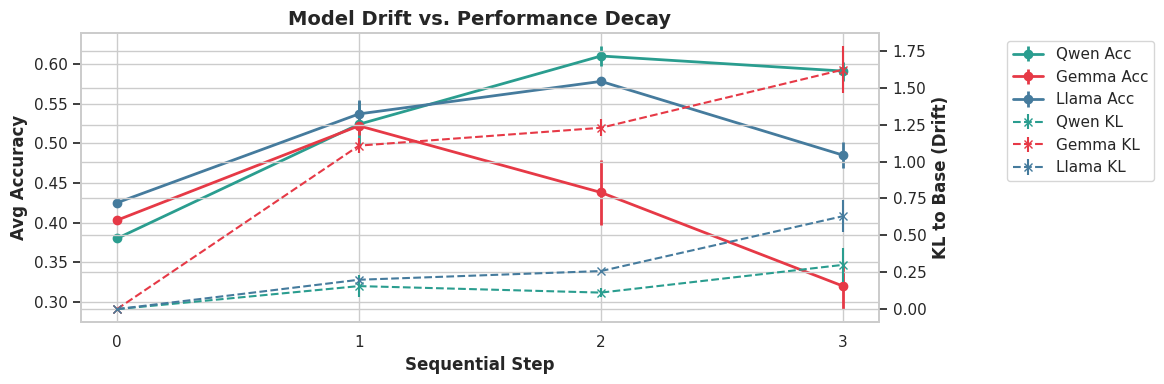

In [10]:
plot_drift_vs_performance(df)

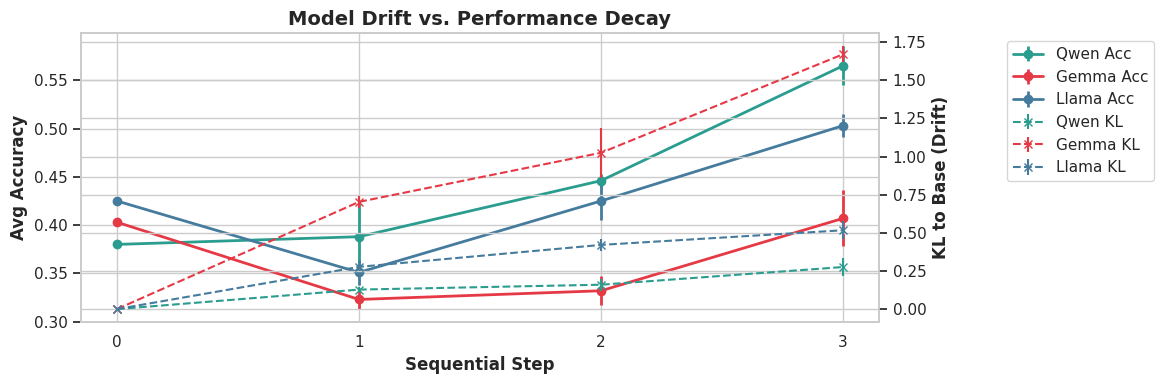

In [18]:
plot_drift_vs_performance(df_321)

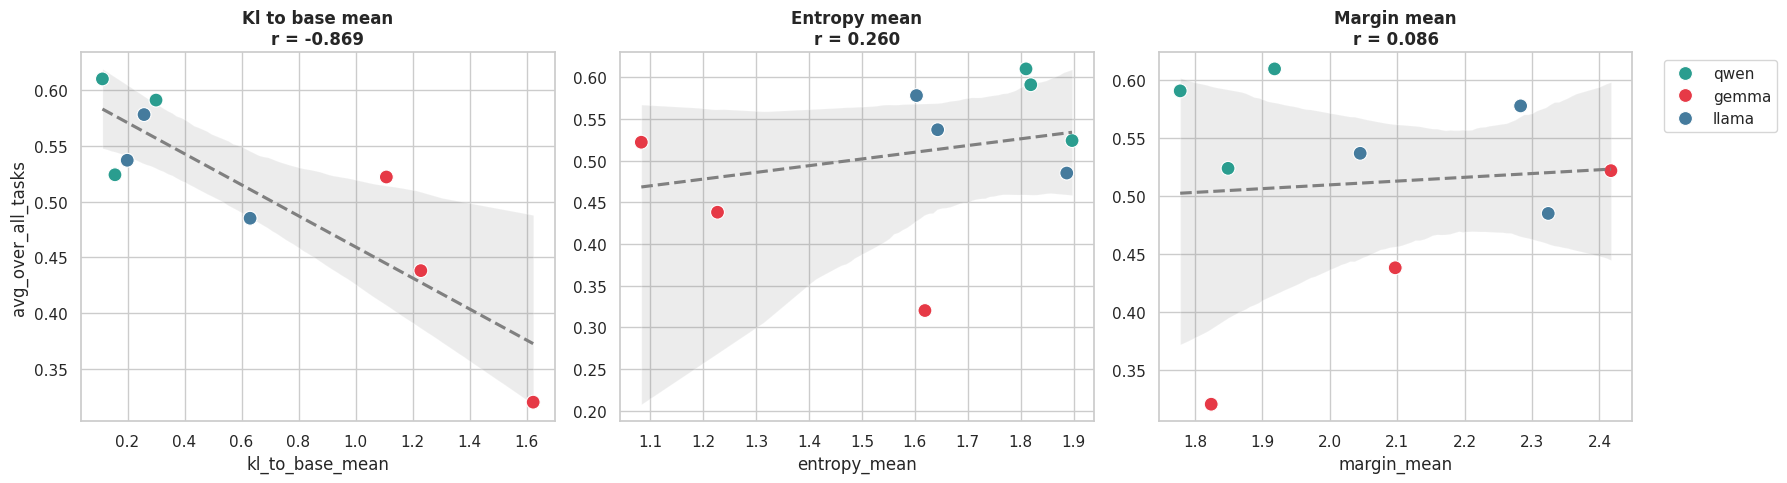

In [14]:
plot_stability_correlations(df)

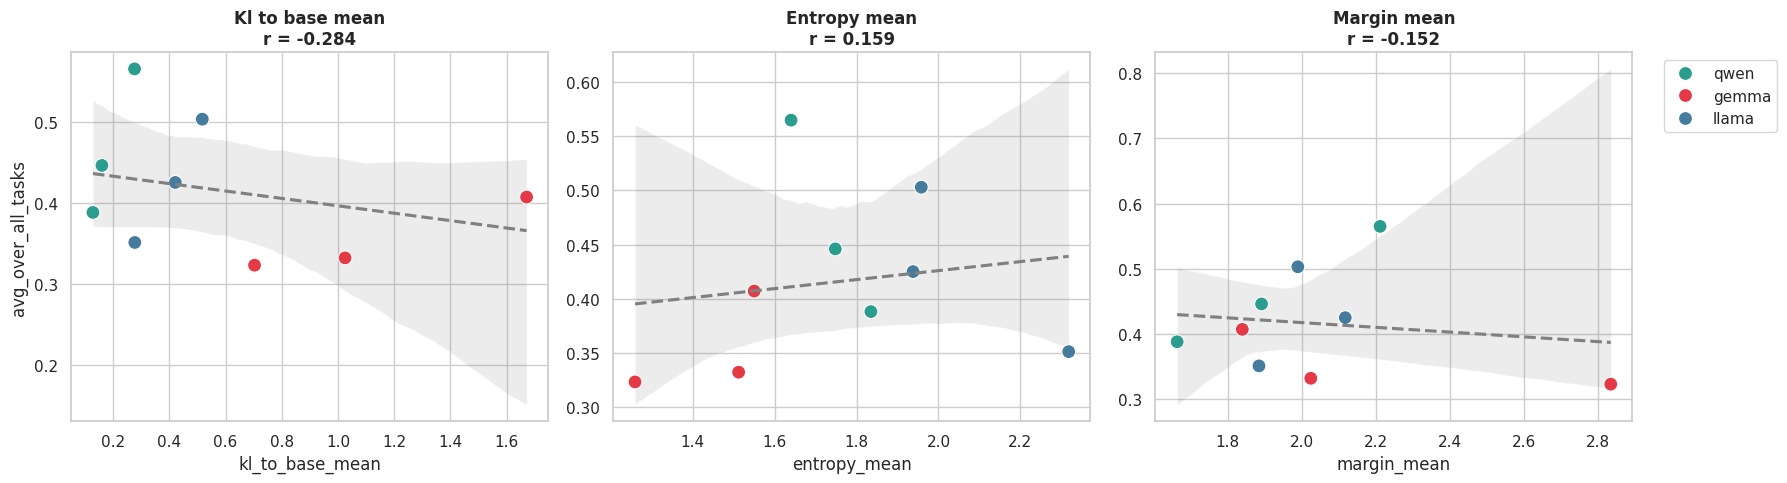

In [19]:
plot_stability_correlations(df_321)

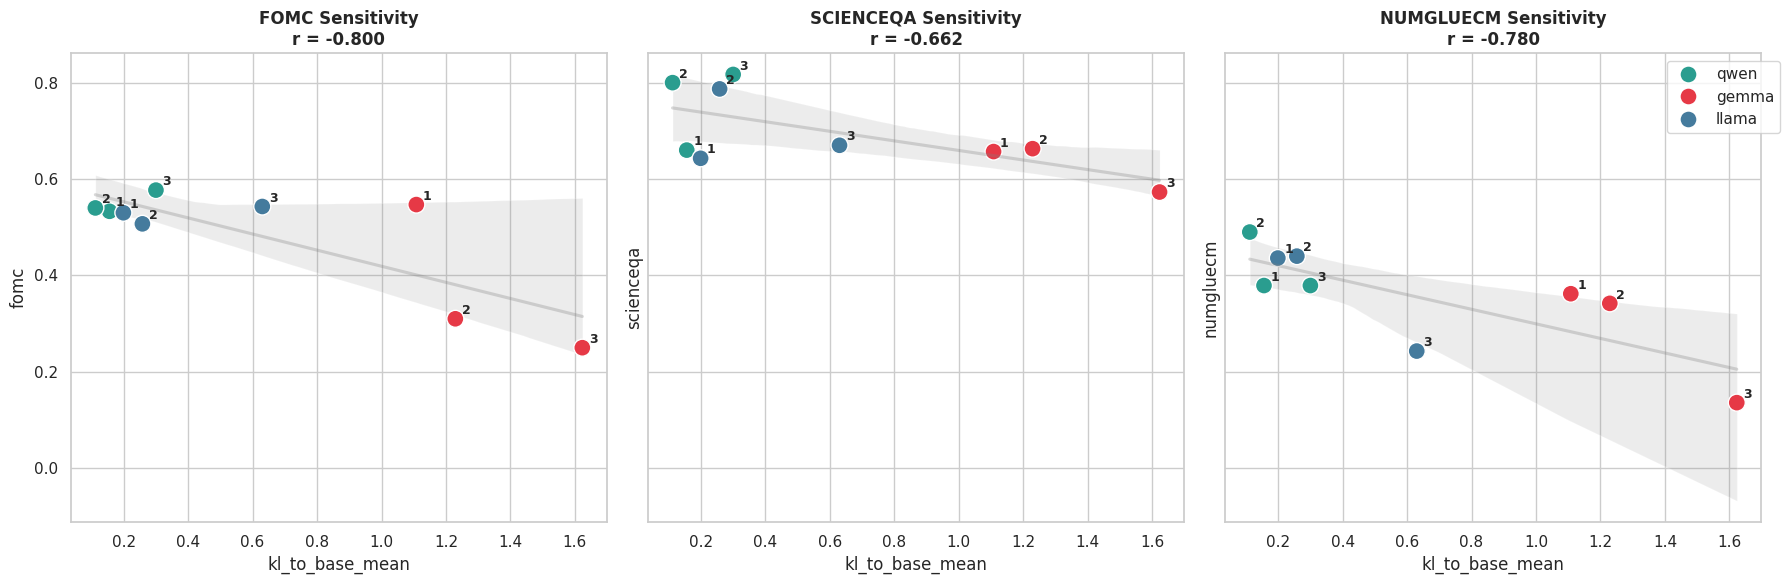

In [15]:
plot_task_sensitivity(df)

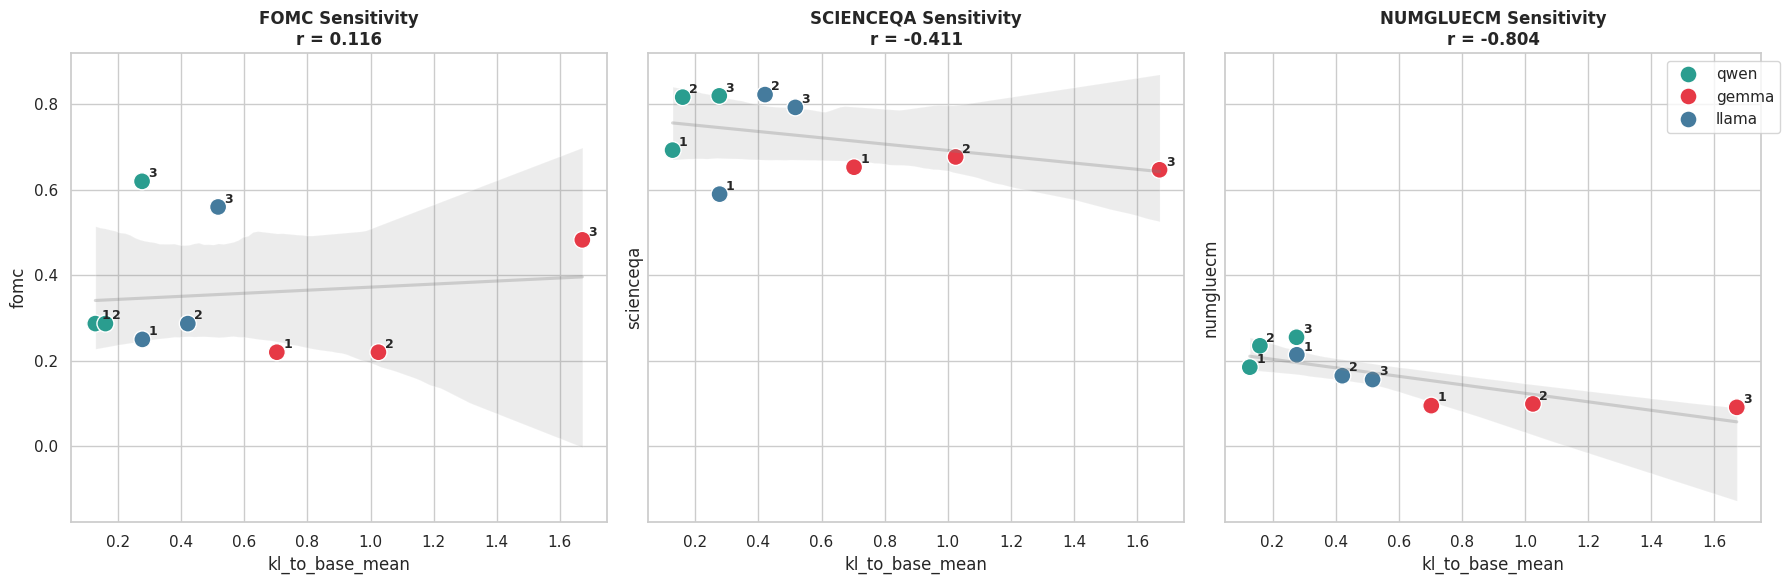

In [20]:
plot_task_sensitivity(df_321)

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import io

# --- 1. THEME & PALETTE ---
plt.rcParams.update({
    "font.family": "serif",
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False
})

MODEL_COLORS = {"gemma": "#D62728", "qwen": "#2CA02C", "llama": "#1F77B4"}

# --- 2. ADAPTED DATA PREPARATION ---
def prepare_comparison_data(csv_orig, csv_rev):
    """Combines both runs and adds a label for the task order."""
    df_orig = pd.read_csv(csv_orig)
    df_orig['order'] = 'Original (1-2-3)'
    
    df_rev = pd.read_csv(csv_rev)
    df_rev['order'] = 'Reversed (3-2-1)'
    
    df = pd.concat([df_orig, df_rev], ignore_index=True)
    
    # Numeric conversion
    numeric_cols = ['avg_over_all_tasks', 'kl_to_base_mean', 'bwt', 'fwt']
    df['model'] = df['model'].astype(str).str.lower()
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col].astype(str).replace('—', None), errors='coerce')
            
    return df.sort_values(['model', 'order', 'step'])

# --- 3. THE CONSISTENCY PLOT ---
def plot_order_robustness(df, name="order_robustness.pdf"):
    """
    Plots Internal Drift (KL) for both runs side-by-side.
    Proves that drift is a property of the model, not the order.
    """
    fig, ax = plt.subplots(figsize=(12, 4))
    
    for model in df['model'].unique():
        for order in df['order'].unique():
            subset = df[(df['model'] == model) & (df['order'] == order)]
            color = MODEL_COLORS.get(model)
            # Use solid line for original, dashed for reversed
            linestyle = '-' if 'Original' in order else '--'
            label = f"{model.capitalize()} ({order})"
            
            ax.plot(subset['step'], subset['kl_to_base_mean'], 
                    marker='o', linestyle=linestyle, color=color, 
                    linewidth=2, label=label)

    ax.set_xticks([0, 1, 2, 3])
    ax.set_xlabel("Sequential Training Step ($k$)")
    ax.set_ylabel(r"KL to Base")
    ax.set_title("Order Invariance of Internal Stability Mechanisms", pad=20, fontweight='bold')
    
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=True)
    plt.tight_layout()
    plt.savefig(name, format="pdf")
    plt.show()

# --- 4. GLOBAL CORRELATION (Both Runs Combined) ---
def plot_global_correlation(df, name="global_correlation.pdf"):
    """
    Correlates Accuracy vs KL using EVERY data point from both runs.
    This provides the final statistical proof for the paper.
    """
    df_degrade = df[df['step'] != 0].dropna(subset=['kl_to_base_mean', 'avg_over_all_tasks'])
    
    plt.figure(figsize=(12, 4))
    r, p = stats.pearsonr(df_degrade['kl_to_base_mean'], df_degrade['avg_over_all_tasks'])
    
    sns.regplot(data=df_degrade, x='kl_to_base_mean', y='avg_over_all_tasks', 
                scatter=False, color='gray', line_kws={'linestyle':'--', 'alpha':0.3})
    
    sns.scatterplot(data=df_degrade, x='kl_to_base_mean', y='avg_over_all_tasks', 
                    hue='model', style='order', s=150, palette=MODEL_COLORS, edgecolor='w')

    plt.title(f"Global Stability Correlation (Across All Task Orders)\nPearson $r = {r:.3f}$, $p < 0.001$", pad=20, fontweight='bold')
    plt.xlabel(r"KL to Base")
    plt.ylabel("Average Accuracy")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(name, format="pdf")
    plt.show()

# --- EXECUTION ---
# Pass your two CSV strings here


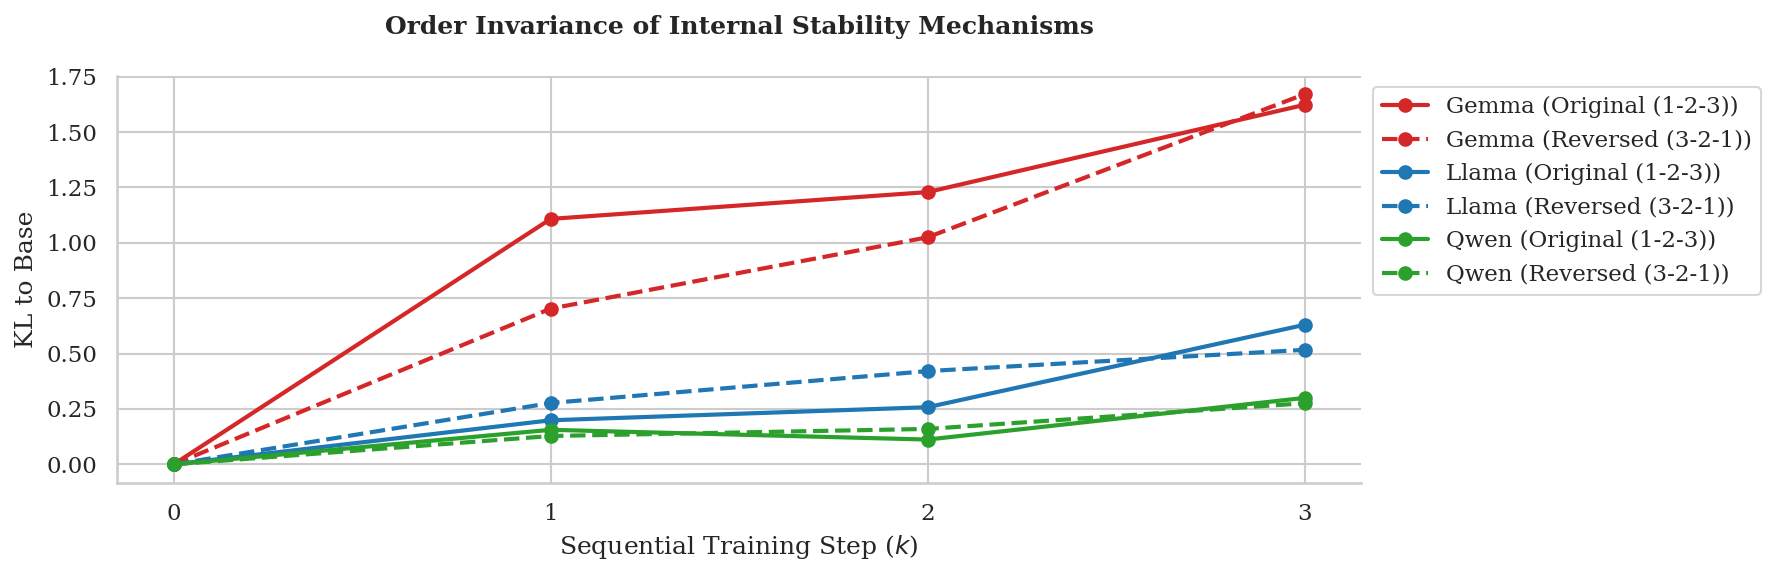

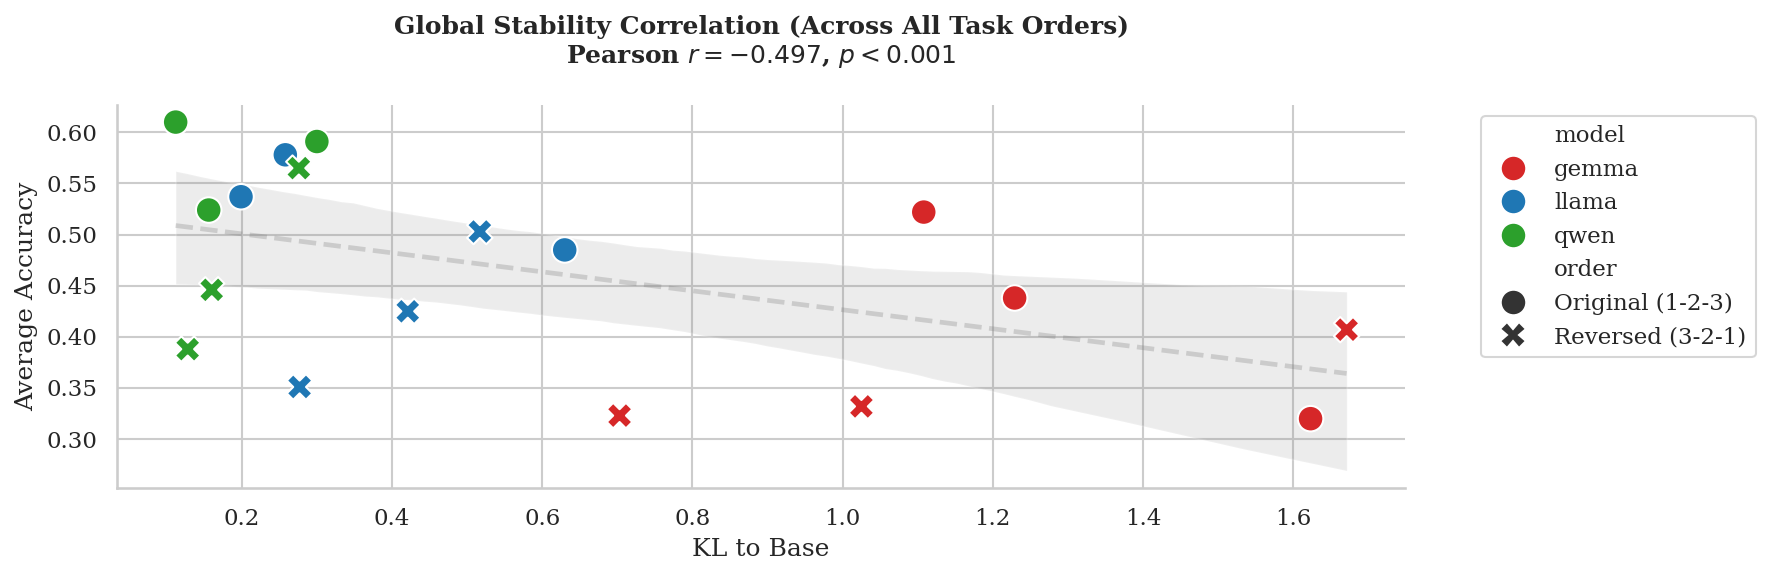

In [39]:
full_df = prepare_comparison_data("combined_df.csv", "combined_df_321.csv")
plot_order_robustness(full_df)
plot_global_correlation(full_df)